In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ECI from RTN Function
def rtn_to_eci(vec_rtn, RAAN, i, w, TA):
    
    TA   = np.radians(TA)
    i    = np.radians(i)
    w    = np.radians(w)
    RAAN = np.radians(RAAN)

    u = w + TA


    R_z_RA = np.array([[np.cos(RAAN), -np.sin(RAAN), 0],
                       [np.sin(RAAN),  np.cos(RAAN), 0],
                       [0, 0, 1]])
    R_x_incl = np.array([[1, 0, 0],
                         [0, np.cos(i), -np.sin(i)],
                         [0, np.sin(i),  np.cos(i)]])
    R_z_u  = np.array([[np.cos(u), -np.sin(u), 0],
                       [np.sin(u),  np.cos(u), 0],
                       [0, 0, 1]])


    Q = np.dot(R_z_RA, np.dot(R_x_incl, R_z_u))

    return np.dot(Q, vec_rtn)

In [20]:
# SV from COE Function
def sv_from_coe(a, e, RAAN, i, w, mu, TA):  

    TA = np.radians(TA)
    i = np.radians(i)
    w = np.radians(w)
    RAAN = np.radians(RAAN)
       
    r_perifocal = a * (1 - e**2) / (1 + e * np.cos(TA)) * np.array([np.cos(TA), np.sin(TA), 0])
    v_perifocal = mu / np.sqrt(mu * a * (1 - e**2)) * np.array([-np.sin(TA), e + np.cos(TA), 0])
    
    R_z_RA = np.array([[np.cos(RAAN), -np.sin(RAAN), 0],
                       [np.sin(RAAN), np.cos(RAAN), 0],
                       [0, 0, 1]])
    
    R_x_incl = np.array([[1, 0, 0],
                         [0, np.cos(i), -np.sin(i)],
                         [0, np.sin(i), np.cos(i)]])
    
    R_z_w = np.array([[np.cos(w), -np.sin(w), 0],
                      [np.sin(w), np.cos(w), 0],
                      [0, 0, 1]])

    Q = np.dot(R_z_RA, np.dot(R_x_incl, R_z_w))

    r = np.dot(Q, r_perifocal)
    v = np.dot(Q, v_perifocal)

    return r, v

In [21]:
# COE from SV Function
def coe_from_sv(R, V):

    eps = 1.e-12

    R = np.array(R)
    V = np.array(V)

    r = np.linalg.norm(R)
    v = np.linalg.norm(V)

    vr = np.dot(R, V) / r

    H = np.cross(R, V)
    h = np.linalg.norm(H)

    incl = np.arccos(H[2] / h)

    N = np.cross([0, 0, 1], H)
    n = np.linalg.norm(N)

    if n != 0:
        RA = np.arccos(N[0] / n)
        if N[1] < 0:
            RA = 2 * np.pi - RA
    else:
        RA = 0

    E = 1 / mu * ((v**2 - mu / r) * R - r * vr * V)
    e = np.linalg.norm(E)

    if n != 0 and e > eps:
        w = np.arccos(np.dot(N, E) / n / e)
        if E[2] < 0:
            w = 2 * np.pi - w
    else:
        w = 0

    if e > eps:
        if np.dot(E, R) / e / r > 1 and np.dot(E, R) / e / r < 1.00000001:
            TA = 0.0
        else:
            TA = np.arccos(np.dot(E, R) / e / r)
        if vr < 0:
            TA = 2 * np.pi - TA
    else:
        cp = np.cross(N, R)
        if cp[2] >= 0:
            TA = np.arccos(np.dot(N, R) / n / r)
        else:
            TA = 2 * np.pi - np.arccos(np.dot(N, R) / n / r)

    a = h**2 / mu / (1 - e**2)


    return a, h, e, np.rad2deg(incl), np.rad2deg(RA), np.rad2deg(w), np.rad2deg(TA)


In [22]:
# Gravitational Parameter
mu = 398600.4415  # gravitational parameter (km^3/s^2)

# Input data
r = [4604.49276873138, 1150.81472538679, 4694.55079634563]  # Position vector in km
v = [-5.10903235110107, -2.48824074138143 , 5.62098648967432]  # Velocity vector in km/s

# Compute the Orbital Elements
coe = coe_from_sv(r, v)

In [23]:
a = coe[0]
h = coe[1]
e = coe[2]
i = coe[3]
RAAN = coe[4]
w = coe[5]
TA = coe[6]

(7178.140779078652, 53359.02455723697, 0.07001161395238599, 96.00000000000003, 19.999999999999993, 43.90440733611482, 1.095592663885542)


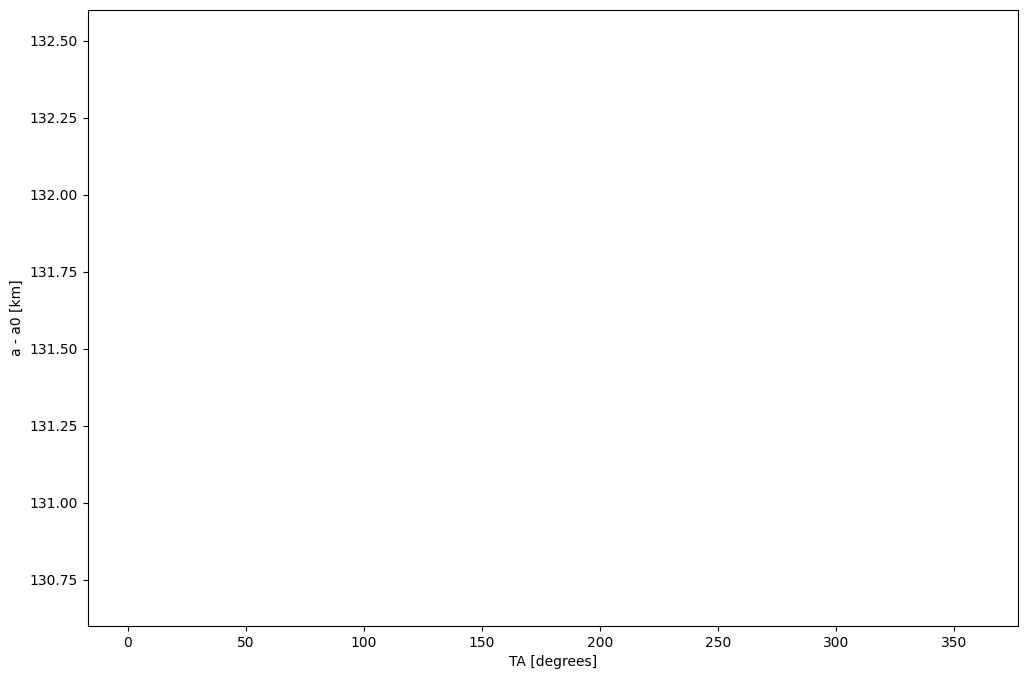

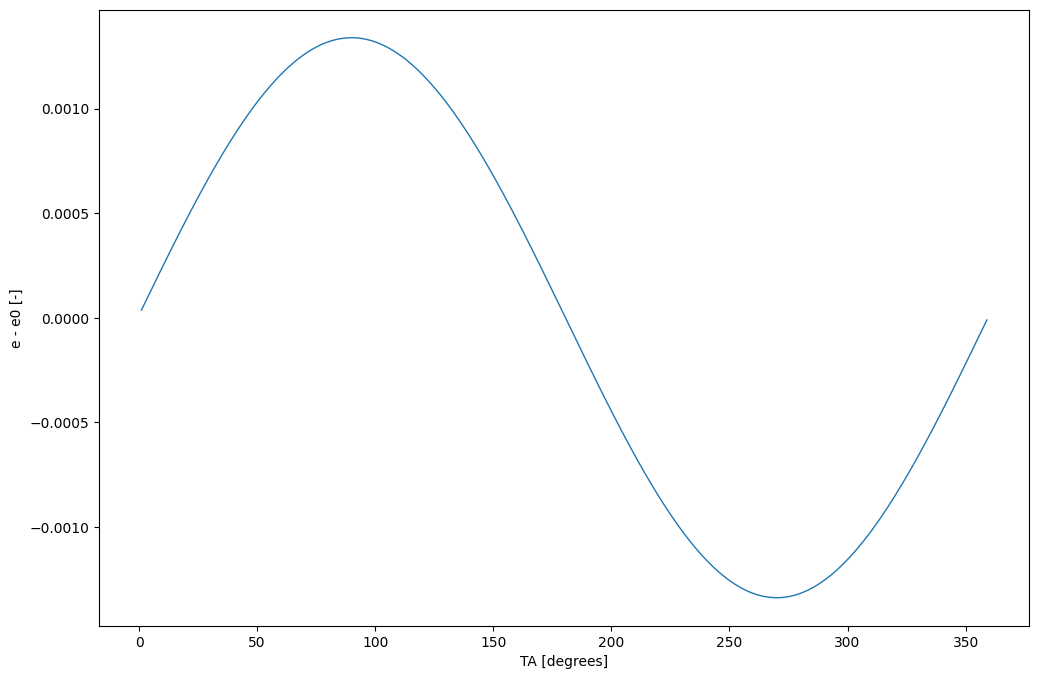

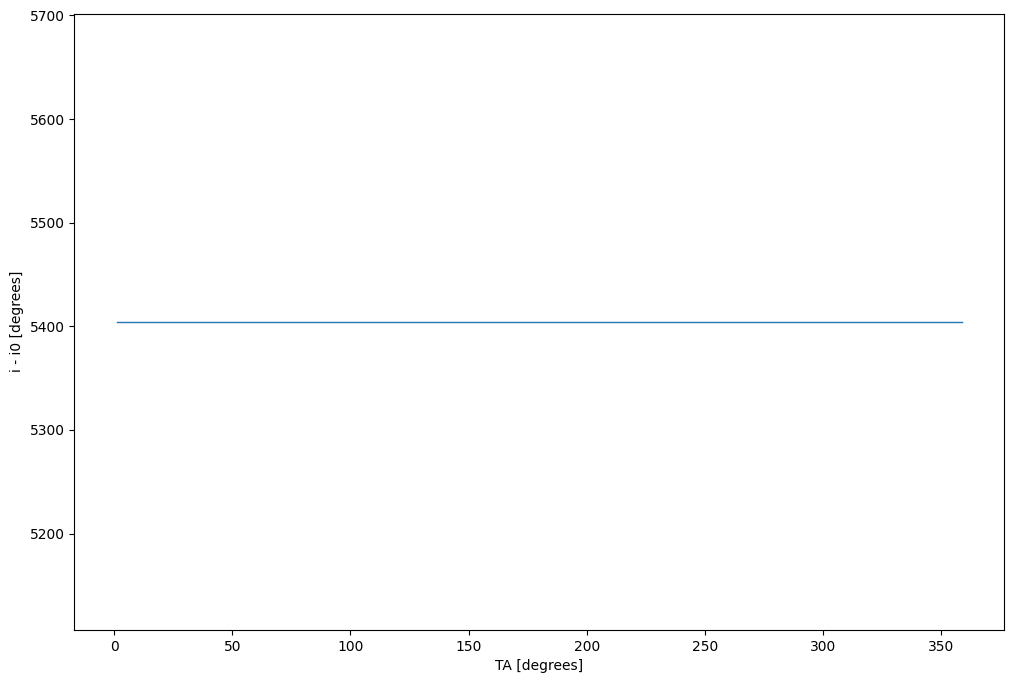

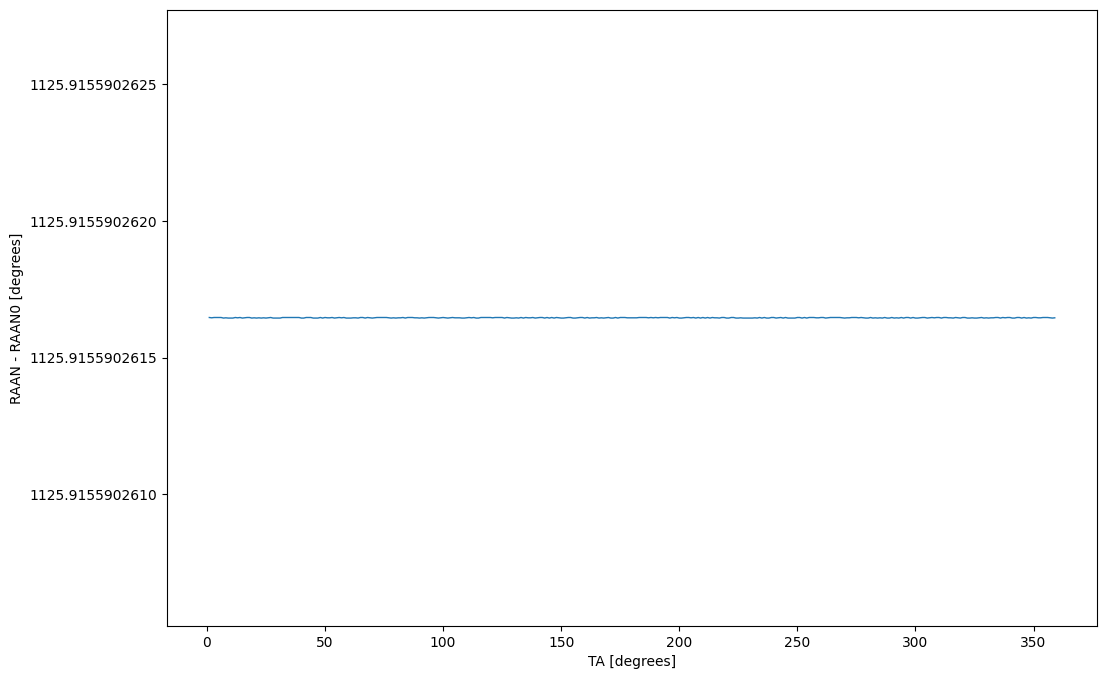

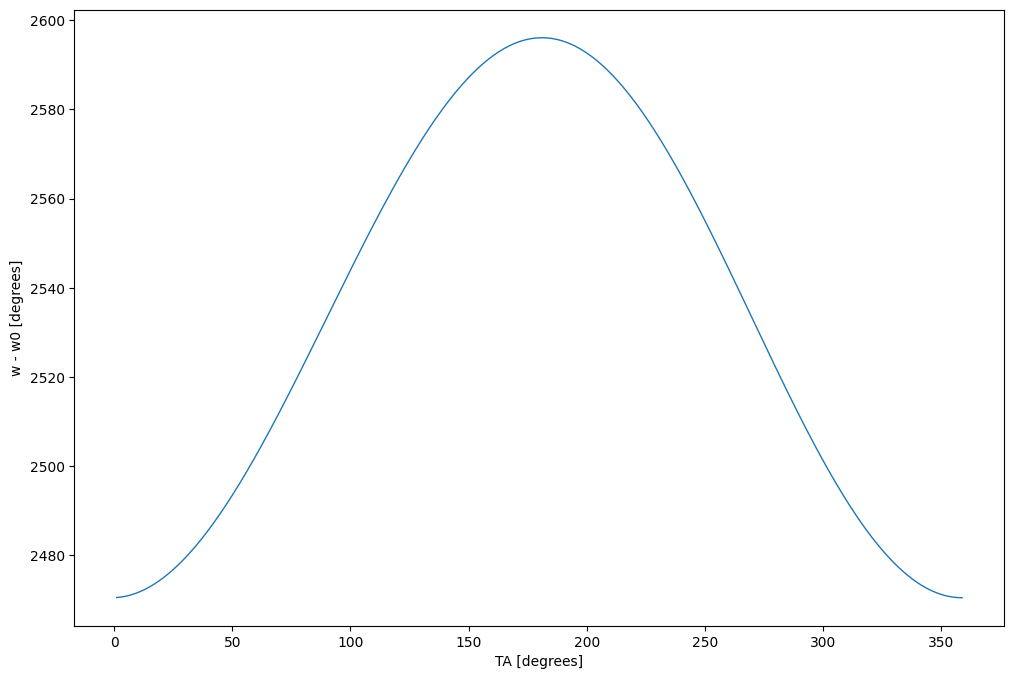

In [24]:
# Defining Maneuvers
DV_r_RTN = np.array([0.01, 0.0, 0.0])
DV_v_RTN = np.array([0.0, 0.01, 0.0])
DV_n_RTN = np.array([0.0, 0.0, 0.01])


# Creating Lists
a_list, e_list, i_list, RAAN_list, w_list, TA_list = [], [], [], [], [], []

DV_ECI = rtn_to_eci(DV_r_RTN, RAAN, i, w, TA)

new_v = v + DV_ECI

coe = coe_from_sv(r, new_v)

print(coe)

# Loop
for TA in range(1,360):

    r, v = sv_from_coe(a, e, RAAN, i, w, mu, TA)

    DV_r_ECI = rtn_to_eci(DV_r_RTN, RAAN, i, w, TA)
    DV_v_ECI = rtn_to_eci(DV_v_RTN, RAAN, i, w, TA)
    DV_n_ECI = rtn_to_eci(DV_n_RTN, RAAN, i, w, TA)

    new_v = v + DV_r_ECI

    coe = coe_from_sv(r, new_v)

    a_list.append(coe[0] - a)
    e_list.append(coe[2] - e)
    i_list.append(np.rad2deg(coe[3]) - i)
    RAAN_list.append(np.rad2deg(coe[4]) - RAAN)
    w_list.append(np.rad2deg(coe[5]) - w)
    TA_list.append(TA)

plt.rcParams['axes.formatter.useoffset'] = False
#plt.rcParams['axes.formatter.limits'] = (-3, 4)  # evita sci tranne casi estremi
    
plt.figure(figsize=(12, 8))
plt.plot(TA_list, a_list, linewidth=1)
plt.xlabel("TA [degrees]")
plt.ylabel("a - a0 [km]")
plt.ylim(130.6,132.6)
plt.show()

plt.figure(figsize=(12, 8))
plt.plot(TA_list, e_list, linewidth=1)
plt.xlabel("TA [degrees]")
plt.ylabel("e - e0 [-]")
plt.show()

plt.figure(figsize=(12, 8))
plt.plot(TA_list, i_list, linewidth=1)
plt.xlabel("TA [degrees]")
plt.ylabel("i - i0 [degrees]")

plt.show()

plt.figure(figsize=(12, 8))
plt.plot(TA_list, RAAN_list, linewidth=1)
plt.xlabel("TA [degrees]")
plt.ylabel("RAAN - RAAN0 [degrees]")

plt.show()

plt.figure(figsize=(12, 8))
plt.plot(TA_list, w_list, linewidth=1)
plt.xlabel("TA [degrees]")
plt.ylabel("w - w0 [degrees]")
plt.show()